# Importing dependencies

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Configuring graphs

In [2]:
plt.rc('font', **{'family':'serif', 'size': 10})
plt.rc('mathtext', **{'fontset':'cm'})
image_resolution = 600
fontsize_label = 12
fontsize_text = 18
fontsize_legend = 10
markers = ['o', 'v', 's', 'X', 'P', 'p', 'D', 'd', 'H', 'h', 'x', '+', '*', '1', '2', '|', '_']
marker_size = 6
cap_size = 3.0
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'teal', 'navy', 'maroon', 'lime']

# Thermophysical properties

In [3]:
def rho(temperature, salinity):
    a = [9.999e2, 2.034e-2, -6.162e-3, 2.261e-5, -4.657e-8]
    b = [8.020e2, -2.001, 1.677e-2, -3.060e-5, -1.613e-5]

    temperature_part = a[0] + a[1] * temperature
    temperature_part += a[2] * temperature * temperature
    temperature_part += a[3] * temperature * temperature * temperature
    temperature_part += a[4] * temperature * temperature * temperature * temperature

    salinity_part = b[0] * salinity
    salinity_part += b[1] * salinity * temperature
    salinity_part += b[2] * salinity * temperature * temperature
    salinity_part += b[3] * salinity * temperature * temperature * temperature
    salinity_part += b[4] * salinity * salinity * temperature * temperature

    return temperature_part + salinity_part

# Establishing directories

In [4]:
figures_dir = os.path.join('./figures/')

os.system('mkdir -p ' + figures_dir)

0

# Loading the cases

In [5]:
cases = pd.read_csv('mais_casos_manhas_81325.csv')
cases = cases.rename(columns={
    'Tf_in': 'Feed temperature at the inlet (°C)',
    'Tc_in': 'Coolant temperature at the inlet (°C)',
    'P_ai gap': 'Vacuum pressure (Pa)',
    'Salinidade': 'Feed salinity at the inlet (g/L)',
    'area da membrana': 'Membrane area (m²)',
    'canais': 'Number of channels',
    'Fluxo experimental': 'Distilled water flux (L/m²h)',
    'incerteza fluxo': 'Distilled water flux uncertainty (L/m²h)',
    'Tf_out': 'Feed temperature at the outlet (°C)',
    'incerteza_tf_out': 'Feed temperature at the outlet uncertainty (°C)',
    'Tc_out': 'Coolant temperature at the outlet (°C)',
    'incerteza_tc_out': 'Coolant temperature at the outlet uncertainty (°C)',
    'Vazao': 'Flow rate (L/h)'
})

numeric_columns = [
    'Feed temperature at the inlet (°C)',
    'Coolant temperature at the inlet (°C)',
    'Vacuum pressure (Pa)',
    'Feed salinity at the inlet (g/L)',
    'Membrane area (m²)',
    'Number of channels',
    'Distilled water flux (L/m²h)',
    'Distilled water flux uncertainty (L/m²h)',
    'Feed temperature at the outlet (°C)',
    'Feed temperature at the outlet uncertainty (°C)',
    'Coolant temperature at the outlet (°C)',
    'Coolant temperature at the outlet uncertainty (°C)',
    'Flow rate (L/h)'
]
cases[numeric_columns] = cases[numeric_columns].apply(pd.to_numeric, errors='coerce')

cases['Case'] = cases['caso'].astype(str) + '-' + cases['sequencia'].astype(int).astype(str)
display(cases)


,caso,sequencia,Feed temperature at the inlet (°C),Coolant temperature at the inlet (°C),Flow rate (L/h),Vacuum pressure (Pa),Feed salinity at the inlet (g/L),Membrane area (m²),Number of channels,Distilled water flux (L/m²h),Distilled water flux uncertainty (L/m²h),Feed temperature at the outlet (°C),Feed temperature at the outlet uncertainty (°C),Coolant temperature at the outlet (°C),Coolant temperature at the outlet uncertainty (°C),Case
0,35.1 gL,1,60,20,400,81325,35.1,25.92,12,0.70,NaN,NaN,NaN,57.2,NaN,35.1 gL-1
1,35.1 gL,2,60,25,400,81325,35.1,25.92,12,0.62,NaN,NaN,NaN,57.8,NaN,35.1 gL-2
2,35.1 gL,3,60,30,400,81325,35.1,25.92,12,0.50,NaN,NaN,NaN,58.0,NaN,35.1 gL-3
3,35.1 gL,4,60,20,800,81325,35.1,25.92,12,1.38,NaN,NaN,NaN,55.3,NaN,35.1 gL-4
4,35.1 gL,5,60,25,800,81325,35.1,25.92,12,1.27,NaN,NaN,NaN,56.8,NaN,35.1 gL-5
5,35.1 gL,6,60,30,800,81325,35.1,25.92,12,1.12,NaN,NaN,NaN,57.2,NaN,35.1 gL-6
6,35.1 gL,7,60,20,1100,81325,35.1,25.92,12,1.82,NaN,NaN,NaN,55.4,NaN,35.1 gL-7
7,35.1 gL,8,60,25,1100,81325,35.1,25.92,12,1.67,NaN,NaN,NaN,55.3,NaN,35.1 gL-8
8,35.1 gL,9,60,30,1100,81325,35.1,25.92,12,1.51,NaN,NaN,NaN,56.7,NaN,35.1 gL-9
9,35.1 gL,10,70,20,400,81325,35.1,25.92,12,0.94,NaN,NaN,NaN,66.3,NaN,35.1 gL-10


# Running the cases

In [6]:
def salinity_equation(x, salinity, temperature):
    return rho(temperature, x) * x - salinity

In [7]:
results = pd.DataFrame(columns=[
    'Case', 'Permeate flux (L/m²h)', 'Exp. permeate flux (L/m²h)', 'Hot feedwater outlet temperature (°C)',
    'Exp. hot feedwater outlet temperature (°C)', 'Cold feedwater outlet temperature (°C)', 'Exp. cold feedwater outlet temperature (°C)',
    'Heat flux (W/m²)', 'Vapor heat flux (W/m²)', 'GOR', 'STECth', 'Thermal efficiency (%)'
])

for index, elem in cases.iterrows():
    hot_feedwater_inlet_temperature = elem['Feed temperature at the inlet (°C)']
    cold_feedwater_inlet_temperature = elem['Coolant temperature at the inlet (°C)']
    vacuum_pressure = -abs(elem['Vacuum pressure (Pa)'])

    initial_guess = elem['Feed salinity at the inlet (g/L)'] / 1000.0
    feed_salinity = fsolve(
        salinity_equation,
        initial_guess,
        args=(elem['Feed salinity at the inlet (g/L)'], elem['Feed temperature at the inlet (°C)'])
    )[0]
    cool_salinity = feed_salinity

    flow_rate = elem['Flow rate (L/h)']
    feed_mass_flow_rate = rho(hot_feedwater_inlet_temperature, feed_salinity) * flow_rate / 3600000.0
    cool_mass_flow_rate = rho(cold_feedwater_inlet_temperature, cool_salinity) * flow_rate / 3600000.0

    membrane_area = elem['Membrane area (m²)']
    number_channels = int(elem['Number of channels'])

    print('Salinity = ', str(elem['Feed salinity at the inlet (g/L)']), ' g/L')
    os.system('./bin/vagmd0Dmodel -entry_temperature_feed ' + str(hot_feedwater_inlet_temperature) +
              ' -entry_temperature_cool ' + str(cold_feedwater_inlet_temperature) +
              ' -feed_mass_flow_rate ' + str(feed_mass_flow_rate) +
              ' -cool_mass_flow_rate ' + str(cool_mass_flow_rate) +
              ' -vacuum_pressure ' + str(vacuum_pressure) +
              ' -entry_salinity_feed ' + str(feed_salinity) +
              ' -entry_salinity_cool ' + str(cool_salinity) +
              ' -membrane_area ' + str(membrane_area) +
              ' -number_channels ' + str(number_channels))

    results_file = pd.read_csv('./results/report.csv')
    latest_result = results_file.iloc[-1]

    mass_flux = latest_result.iloc[11]
    film_temperature = latest_result.iloc[4]
    hot_feedwater_outlet_temperature = latest_result.iloc[1]
    cold_feedwater_outlet_temperature = latest_result.iloc[2]
    heat_flux = latest_result.iloc[13]
    vapor_heat_flux = latest_result.iloc[15]
    GOR = latest_result.iloc[17]
    STECth = latest_result.iloc[19]
    thermal_efficiency = latest_result.iloc[18]

    new_row = pd.DataFrame([{
        'Case': elem['Case'],
        'Permeate flux (L/m²h)': 1000.0 * mass_flux / rho(film_temperature, 0.0),
        'Exp. permeate flux (L/m²h)': elem['Distilled water flux (L/m²h)'],
        'Hot feedwater outlet temperature (°C)': hot_feedwater_outlet_temperature,
        'Exp. hot feedwater outlet temperature (°C)': elem['Feed temperature at the outlet (°C)'],
        'Cold feedwater outlet temperature (°C)': cold_feedwater_outlet_temperature,
        'Exp. cold feedwater outlet temperature (°C)': elem['Coolant temperature at the outlet (°C)'],
        'Heat flux (W/m²)': heat_flux,
        'Vapor heat flux (W/m²)': vapor_heat_flux,
        'GOR': GOR,
        'STECth': STECth,
        'Thermal efficiency (%)': thermal_efficiency
    }])
    results = pd.concat([results, new_row], ignore_index=True)


Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L
Salinity =  70.1  g/L


In [8]:
display(results)

,Case,Permeate flux (L/m²h),Exp. permeate flux (L/m²h),Hot feedwater outlet temperature (°C),Exp. hot feedwater outlet temperature (°C),Cold feedwater outlet temperature (°C),Exp. cold feedwater outlet temperature (°C),Heat flux (W/m²),Vapor heat flux (W/m²),GOR,STECth,Thermal efficiency (%)
0,35.1 gL-1,0.70333,0.7,22.816431,NaN,56.579914,57.2,643.802192,448.688682,7.439368,85.783382,69.693562
1,35.1 gL-2,0.623699,0.62,27.433346,NaN,57.082878,57.8,564.052036,396.67983,7.720984,82.40078,70.326815
2,35.1 gL-3,0.53694,0.5,32.079298,NaN,57.550402,58.0,483.751934,340.443163,7.902885,80.252337,70.375566
3,35.1 gL-4,1.412972,1.38,24.548304,NaN,54.881483,55.3,1227.726947,900.244546,4.987193,127.832382,73.326121
4,35.1 gL-5,1.264416,1.27,28.89078,NaN,55.650847,56.8,1077.680703,803.279357,5.243902,121.217107,74.537788
5,35.1 gL-6,1.101786,1.12,33.281446,NaN,56.366675,57.2,925.883295,697.904745,5.461692,116.033897,75.377183
6,35.1 gL-7,1.910971,1.82,25.686402,NaN,53.765749,55.4,1634.046383,1216.595975,4.024633,158.312889,74.452965
7,35.1 gL-8,1.714622,1.67,29.852299,NaN,54.706502,55.3,1436.09543,1088.563903,4.246433,149.614748,75.800248
8,35.1 gL-9,1.499205,1.51,34.077432,NaN,55.5833,56.7,1235.220284,949.098814,4.443912,142.547545,76.836401
9,35.1 gL-10,0.946868,0.94,23.090868,NaN,65.881174,66.3,807.777929,599.225683,8.240497,76.831301,74.181983


In [9]:
100.0 * (results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

0      0.475701
1      0.596666
2      7.388055
3      2.389248
4     -0.439646
5     -1.626221
6      4.998385
7      2.671977
8     -0.714917
9      0.730688
10     4.754816
11     4.208868
12     2.462455
13     0.891792
14     8.802966
15     4.362646
16    -0.114391
17     4.789191
18      7.09666
19      8.09153
20     4.780017
21     10.34792
22     8.986141
23     4.068397
24    16.239415
25     6.423124
26     6.962102
27    10.383197
28     6.963696
29     5.932016
30     5.385875
31    13.801193
32    11.324499
33     9.142979
34     8.260591
35    14.703139
36     9.638801
37    10.330042
38    13.898647
39     7.403502
40    13.458527
41    10.934826
42    13.452973
43    11.910886
44    11.982341
dtype: object

# Plot the results for different salinities

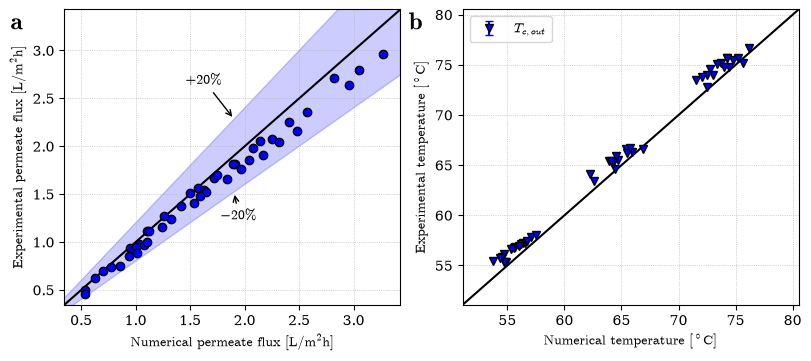

In [12]:
# %% [markdown]
# # Plot the results for different salinities

# %%
# --- PARTE DO FLUXO ---
flux_x = pd.to_numeric(results['Permeate flux (L/m²h)'], errors='coerce').to_numpy(dtype=float)
flux_y = pd.to_numeric(results['Exp. permeate flux (L/m²h)'], errors='coerce').to_numpy(dtype=float)
flux_err = pd.to_numeric(cases['Distilled water flux uncertainty (L/m²h)'], errors='coerce').to_numpy(dtype=float)

flux_mask = np.isfinite(flux_x) & np.isfinite(flux_y)

# Proteção caso o array de fluxo venha vazio
if flux_mask.sum() > 0:
    min_mass_flux = 0.75 * np.nanmin([np.nanmin(flux_x[flux_mask]), np.nanmin(flux_y[flux_mask])])
    max_mass_flux = 1.05 * np.nanmax([np.nanmax(flux_x[flux_mask]), np.nanmax(flux_y[flux_mask])])
else:
    min_mass_flux, max_mass_flux = 0.0, 10.0

mass_flux_line = np.linspace(min_mass_flux, max_mass_flux, 100)

# --- PARTE DA TEMPERATURA (COLD) ---
cold_x = pd.to_numeric(results['Cold feedwater outlet temperature (°C)'], errors='coerce').to_numpy(dtype=float)
cold_y = pd.to_numeric(results['Exp. cold feedwater outlet temperature (°C)'], errors='coerce').to_numpy(dtype=float)
cold_err = pd.to_numeric(cases['Coolant temperature at the outlet uncertainty (°C)'], errors='coerce').to_numpy(dtype=float)

cold_mask = np.isfinite(cold_x) & np.isfinite(cold_y)
temperature_values = np.concatenate([cold_x[cold_mask], cold_y[cold_mask]])

if len(temperature_values) > 0:
    min_temperature = 0.95 * np.nanmin(temperature_values)
    max_temperature = 1.05 * np.nanmax(temperature_values)
else:
    min_temperature, max_temperature = 0.0, 100.0

temperature_line = np.linspace(min_temperature, max_temperature, 100)

# --- PLOTAGEM ---
figval, axsval = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

# Gráfico 1: Fluxo
axsval[0].errorbar(
    flux_x[flux_mask],
    flux_y[flux_mask],
    yerr=flux_err[flux_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, linestyle='None'
)
axsval[0].plot(mass_flux_line, mass_flux_line, color='black')
axsval[0].fill_between(mass_flux_line, 0.8 * mass_flux_line, 1.2 * mass_flux_line, color='blue', alpha=0.2)
axsval[0].annotate(r'$\mathrm{+20\%}$', xy=(mass_flux_line[50], 1.2 * mass_flux_line[50]), xytext=(-35, 25), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].annotate(r'$\mathrm{-20\%}$', xy=(mass_flux_line[50], 0.8 * mass_flux_line[50]), xytext=(-10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].set_xlim(min_mass_flux, max_mass_flux)
axsval[0].set_ylim(min_mass_flux, max_mass_flux)
axsval[0].grid(linestyle='dotted', linewidth=0.5)
axsval[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axsval[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')

# Gráfico 2: Temperatura (Cold)
axsval[1].errorbar(
    cold_x[cold_mask],
    cold_y[cold_mask],
    yerr=cold_err[cold_mask],
    marker=markers[1], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, label=r'$T_{c,out}$', linestyle='None'
)
axsval[1].plot(temperature_line, temperature_line, color='black')
axsval[1].set_xlim(min_temperature, max_temperature)
axsval[1].set_ylim(min_temperature, max_temperature)
axsval[1].legend(fontsize=fontsize_legend)
axsval[1].grid(linestyle='dotted', linewidth=0.5)
axsval[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axsval[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

axsval[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axsval[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axsval[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axsval[1].transAxes, fontsize=fontsize_text, fontweight='bold')

figval.savefig(figures_dir + 'validation_salinity.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)

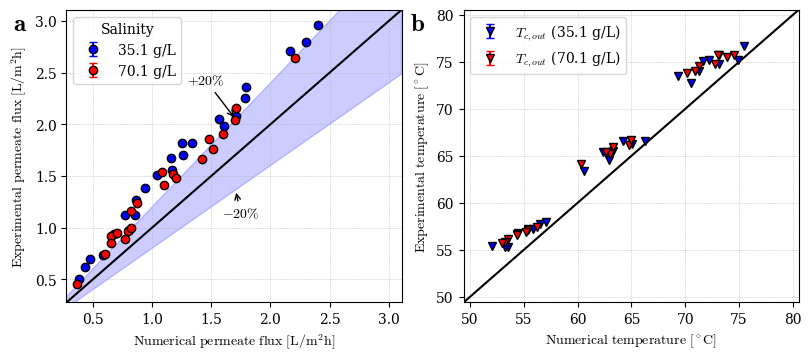

In [ ]:
# --- EXTRAÇÃO DE SALINIDADE ---
# Lê a coluna 'Case' do dataframe 'results', separa pelo espaço (ex: de '35.1 gL-1' para '35.1') e converte para número real
salinities = results['Case'].apply(lambda x: float(str(x).split()[0])).to_numpy()
unique_salinities = np.unique(salinities[np.isfinite(salinities)])

# --- PARTE DO FLUXO ---
flux_x = results['Permeate flux (L/m²h)'].to_numpy()
flux_y = results['Exp. permeate flux (L/m²h)'].to_numpy()
flux_err = cases['Distilled water flux uncertainty (L/m²h)'].to_numpy()
flux_mask = np.isfinite(flux_x) & np.isfinite(flux_y)

if flux_mask.sum() > 0:
    min_mass_flux = 0.75 * np.nanmin([np.nanmin(flux_x[flux_mask]), np.nanmin(flux_y[flux_mask])])
    max_mass_flux = 1.05 * np.nanmax([np.nanmax(flux_x[flux_mask]), np.nanmax(flux_y[flux_mask])])
else:
    min_mass_flux, max_mass_flux = 0.0, 10.0

mass_flux_line = np.linspace(min_mass_flux, max_mass_flux, 100)

# --- PARTE DA TEMPERATURA (Apenas COLD) ---
cold_x = results['Cold feedwater outlet temperature (°C)'].to_numpy()
cold_y = results['Exp. cold feedwater outlet temperature (°C)'].to_numpy()
cold_err = cases['Coolant temperature at the outlet uncertainty (°C)'].to_numpy()
cold_mask = np.isfinite(cold_x) & np.isfinite(cold_y)

temperature_values = np.concatenate([cold_x[cold_mask], cold_y[cold_mask]])

if len(temperature_values) > 0:
    min_temperature = 0.95 * np.nanmin(temperature_values)
    max_temperature = 1.05 * np.nanmax(temperature_values)
else:
    min_temperature, max_temperature = 0.0, 100.0

temperature_line = np.linspace(min_temperature, max_temperature, 100)

# --- PLOTAGEM ---
figval, axsval = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

# Linhas de referência (Gráfico 1)
axsval[0].plot(mass_flux_line, mass_flux_line, color='black')
axsval[0].fill_between(mass_flux_line, 0.8 * mass_flux_line, 1.2 * mass_flux_line, color='blue', alpha=0.2)
axsval[0].annotate(r'$\mathrm{+20\%}$', xy=(mass_flux_line[50], 1.2 * mass_flux_line[50]), xytext=(-35, 25), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].annotate(r'$\mathrm{-20\%}$', xy=(mass_flux_line[50], 0.8 * mass_flux_line[50]), xytext=(-10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

# Linhas de referência (Gráfico 2)
axsval[1].plot(temperature_line, temperature_line, color='black')

# Loop para plotar cada salinidade com uma cor diferente
for i, sal in enumerate(unique_salinities):
    # Escolhe a cor baseada no índice (reaproveitando a lista 'colors')
    current_color = colors[i % len(colors)]
    
    # Máscaras específicas para cruzar os dados válidos com a salinidade atual
    sal_flux_mask = flux_mask & (salinities == sal)
    sal_cold_mask = cold_mask & (salinities == sal)
    
    # Plota Fluxo
    if sal_flux_mask.sum() > 0:
        axsval[0].errorbar(
            flux_x[sal_flux_mask], flux_y[sal_flux_mask], yerr=flux_err[sal_flux_mask],
            marker=markers[0], markersize=marker_size, markeredgecolor='black',
            color=current_color, capsize=cap_size, linestyle='None',
            label=f'{sal:g} g/L'
        )
        
    # Plota Temperatura Cold com a indicação Tc,out na legenda
    if sal_cold_mask.sum() > 0:
        axsval[1].errorbar(
            cold_x[sal_cold_mask], cold_y[sal_cold_mask], yerr=cold_err[sal_cold_mask],
            marker=markers[1], markersize=marker_size, markeredgecolor='black',
            color=current_color, capsize=cap_size, linestyle='None',
            label=r'$T_{c,out}$ (' + f'{sal:g} g/L)'
        )

# Configurações Finais - Gráfico 1 (Fluxo)
axsval[0].set_xlim(min_mass_flux, max_mass_flux)
axsval[0].set_ylim(min_mass_flux, max_mass_flux)
axsval[0].grid(linestyle='dotted', linewidth=0.5)
axsval[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axsval[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')
axsval[0].legend(fontsize=fontsize_legend, title='Salinity') 

# Configurações Finais - Gráfico 2 (Temperatura)
axsval[1].set_xlim(min_temperature, max_temperature)
axsval[1].set_ylim(min_temperature, max_temperature)
axsval[1].grid(linestyle='dotted', linewidth=0.5)
axsval[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axsval[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')
axsval[1].legend(fontsize=fontsize_legend)

# Textos 'a' e 'b'
axsval[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axsval[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axsval[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axsval[1].transAxes, fontsize=fontsize_text, fontweight='bold')

figval.savefig(figures_dir + 'validation_salinity.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)

In [ ]:
# Quantidade de pontos no gráfico de fluxo de permeado (Gráfico a)
qtd_fluxo = flux_mask.sum()
print(f"Pontos plotados no gráfico de fluxo de permeado: {qtd_fluxo}")

# Quantidade de pontos no gráfico de temperatura (Gráfico b)
qtd_hot = hot_mask.sum()
qtd_cold = cold_mask.sum()
print(f"Pontos Tf,out plotados no gráfico de temperatura: {qtd_hot}")
print(f"Pontos Tc,out plotados no gráfico de temperatura: {qtd_cold}")
print(f"Total de pontos no gráfico de temperatura: {qtd_hot + qtd_cold}")

Pontos plotados no gráfico de fluxo de permeado: 45
Pontos Tf,out plotados no gráfico de temperatura: 0
Pontos Tc,out plotados no gráfico de temperatura: 45
Total de pontos no gráfico de temperatura: 45


In [ ]:
import os

# 1. Adiciona uma nova coluna com o desvio percentual absoluto
results['Deviation (%)'] = 100.0 * abs(results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

# 2. Cria as máscaras para separar os dados (<= 20% e > 20%)
mask_within_20 = results['Deviation (%)'] <= 20.0
mask_above_20 = results['Deviation (%)'] > 20.0

# 3. Separa os resultados em dois DataFrames distintos
df_within_20 = results[mask_within_20]
df_above_20 = results[mask_above_20]

# 4. Garante que o diretório existe e exporta para CSV
os.makedirs('./results', exist_ok=True)
df_within_20.to_csv('./results/desvios_ate_20.csv', index=False)
df_above_20.to_csv('./results/desvios_acima_de_20.csv', index=False)

print(f"Arquivos CSV gerados com sucesso!")
print(f"-> Casos com desvio de até 20%: {len(df_within_20)}")
print(f"-> Casos com desvio maior que 20%: {len(df_above_20)}")

Arquivos CSV gerados com sucesso!
-> Casos com desvio de até 20%: 17
-> Casos com desvio maior que 20%: 28


In [ ]:
# 3. Recalcula os limites do fluxo de permeado
min_mass_flux_final = 0.75 * np.nanmin([np.nanmin(flux_x[final_mask]), np.nanmin(flux_y[final_mask])])
max_mass_flux_final = 1.05 * np.nanmax([np.nanmax(flux_x[final_mask]), np.nanmax(flux_y[final_mask])])

# AJUSTE: Linha base parte de 0 até um valor muito maior, cruzando toda a tela
mass_flux_line_final = np.linspace(0, max_mass_flux_final * 1.5, 100)

# 4. Recalcula os limites de temperatura
temp_values_final = np.concatenate([
    hot_x[final_mask], hot_y[final_mask], 
    cold_x[final_mask], cold_y[final_mask]
])
min_temp_final = 0.95 * np.nanmin(temp_values_final)
max_temp_final = 1.05 * np.nanmax(temp_values_final)

# AJUSTE: Fazemos o mesmo para a reta de temperaturas
temp_line_final = np.linspace(0, max_temp_final * 1.5, 100)

# 5. Configura a figura com dois gráficos (1 linha, 2 colunas)
fig_final, axs_final = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

# ----------------- Gráfico a: Fluxo de Permeado (Desvio <= 20%) -----------------
axs_final[0].errorbar(
    flux_x[final_mask],
    flux_y[final_mask],
    yerr=flux_err[final_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, linestyle='None'
)
axs_final[0].plot(mass_flux_line_final, mass_flux_line_final, color='black')
axs_final[0].fill_between(mass_flux_line_final, 0.8 * mass_flux_line_final, 1.2 * mass_flux_line_final, color='blue', alpha=0.2)

# AJUSTE: Coordenadas calculadas dinamicamente com base na área visível
# Pegamos pontos que estão a 30% (para o -20%) e a 70% (para o +20%) da janela visível
x_range = max_mass_flux_final - min_mass_flux_final
x_down = min_mass_flux_final + 0.30 * x_range
x_up = min_mass_flux_final + 0.70 * x_range

axs_final[0].annotate(r'$\mathrm{+20\%}$', xy=(x_up, 1.2 * x_up), 
                      xytext=(-45, 5), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axs_final[0].annotate(r'$\mathrm{-20\%}$', xy=(x_down, 0.8 * x_down), 
                      xytext=(0, -30), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

# AJUSTE: Trava os eixos firmemente para recortar as sobras da linha e evitar margens em branco
axs_final[0].set_xlim(min_mass_flux_final, max_mass_flux_final)
axs_final[0].set_ylim(min_mass_flux_final, max_mass_flux_final)
axs_final[0].grid(linestyle='dotted', linewidth=0.5)
axs_final[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axs_final[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')

# ----------------- Gráfico b: Temperaturas -----------------
axs_final[1].errorbar(
    hot_x[final_mask],
    hot_y[final_mask],
    yerr=hot_err[final_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[1], capsize=cap_size, label=r'$T_{f,out}$', linestyle='None'
)
axs_final[1].errorbar(
    cold_x[final_mask],
    cold_y[final_mask],
    yerr=cold_err[final_mask],
    marker=markers[1], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, label=r'$T_{c,out}$', linestyle='None'
)
axs_final[1].plot(temp_line_final, temp_line_final, color='black')
axs_final[1].set_xlim(min_temp_final, max_temp_final)
axs_final[1].set_ylim(min_temp_final, max_temp_final)
axs_final[1].legend(fontsize=fontsize_legend)
axs_final[1].grid(linestyle='dotted', linewidth=0.5)
axs_final[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axs_final[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

# ----------------- Formatação Final e Salvamento -----------------
axs_final[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axs_final[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axs_final[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axs_final[1].transAxes, fontsize=fontsize_text, fontweight='bold')

fig_final.savefig(figures_dir + 'validation_strict_20_percent_fixed.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)

plt.show()

# 6. Imprime a quantidade
qtd_final = final_mask.sum()
print(f"Total de experimentos com informações completas e desvio <= 20%: {qtd_final}")
print(f"-> O gráfico 'a' possui {qtd_final} pontos plotados.")
print(f"-> O gráfico 'b' possui {qtd_final * 2} pontos plotados ({qtd_final} de Tf,out e {qtd_final} de Tc,out).")

NameError: name 'final_mask' is not defined

In [ ]:
import os

# Filtra o DataFrame de resultados usando a máscara final (completos e <= 20% desvio)
df_casos_grafico = results[final_mask]

# Garante que o diretório existe e exporta para CSV
os.makedirs('./results', exist_ok=True)
caminho_csv = './results/casos_grafico_final.csv'
df_casos_grafico.to_csv(caminho_csv, index=False)

print(f"\nArquivo '{caminho_csv}' gerado com sucesso!")
print(f"Total de linhas exportadas: {len(df_casos_grafico)}")


Arquivo './results/casos_grafico_final.csv' gerado com sucesso!
Total de linhas exportadas: 41
